First Five Rows:
    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  
2  

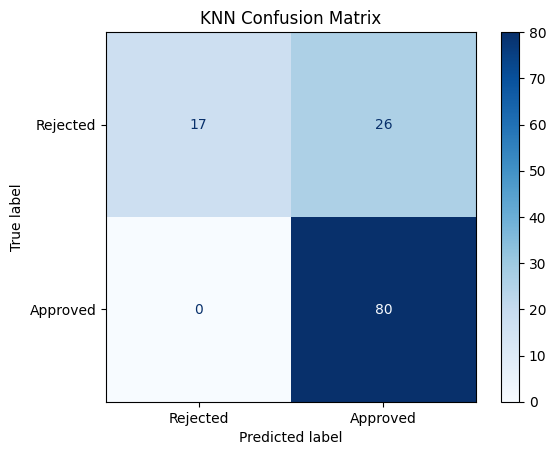


Prediction: Loan Approved


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Load dataset
df = pd.read_csv("train.csv")

# Display first five rows
print("First Five Rows:")
print(df.head())

# Check missing values
print("\nMissing Values Before Filling:")
print(df.isnull().sum())

# Fill missing values
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
cat_cols = df.select_dtypes(include=["object"]).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\nMissing Values After Filling:")
print(df.isnull().sum())

# Encode categorical variables
label_encoder = LabelEncoder()

for col in cat_cols:
    df[col] = label_encoder.fit_transform(df[col])

print("\nEncoded Dataset:")
print(df.head())

# Features and target
X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train default KNN model
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

default_accuracy = accuracy_score(y_test, y_pred)
print("\nDefault KNN Accuracy:", default_accuracy)

# Experiment with different K values
print("\nAccuracy for Different K Values:")
for k in [3, 5, 7]:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    print(f"K = {k}: Accuracy = {acc:.4f}")

# Hyperparameter tuning
param_grid = {
    "n_neighbors": [3, 5, 7, 9, 11, 13]
}

grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train, y_train)

print("\nBest Parameters:", grid.best_params_)
print("Best Cross Validation Accuracy:", grid.best_score_)

# Best model prediction
best_knn = grid.best_estimator_
best_predictions = best_knn.predict(X_test)

# Model evaluation
best_accuracy = accuracy_score(y_test, best_predictions)
cm = confusion_matrix(y_test, best_predictions)

print("\nBest KNN Accuracy:", best_accuracy)
print("\nConfusion Matrix:")
print(cm)

# Plot Confusion Matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Rejected", "Approved"]
)

disp.plot(cmap="Blues")
plt.title("KNN Confusion Matrix")
plt.show()

# Sample prediction
sample = X_test[0].reshape(1, -1)
prediction = best_knn.predict(sample)

if prediction[0] == 1:
    print("\nPrediction: Loan Approved")
else:
    print("\nPrediction: Loan Rejected")